# Модель стоимости квартир в Москве и МО по объявлениям о продаже

**Цель:** построить модель, предсказывающую цену квартиры в объявлении (`price`), обосновать решения и интерпретировать результат для заказчика.

**Структура ноутбука**

1. Импорты и конфигурация
2. Постановка ML-задачи
3. Выбор метрики
4. Загрузка данных и базовые характеристики
5. Разведочный анализ (EDA)
6. Предобработка и генерация признаков
7. Разбиение на train/test
8. Константная модель
9. Бейзлайн: Ridge-регрессия
10. Градиентный бустинг LightGBM: подбор гиперпараметров (scikit-learn и Optuna)
11. Интерпретация модели (SHAP, permutation importance)
12. Итоги для заказчика

Функции, которые вызываются несколько раз или содержат ветвления (генерация признаков, метрики), вынесены в модуль `helpers.py` рядом с ноутбуком.
Версии библиотек зафиксированы в `requirements.txt`.

## 1. Импорты и конфигурация

In [1]:
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import loguniform, randint, uniform
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from helpers import (
    CATEGORICAL_FEATURES,
    TEXT_FLAGS,
    build_features,
    categories_to_codes,
    haversine_km,
    make_listing_groups,
    mape_optimal_constant,
    regression_report,
    shap_contribution_table,
)

In [2]:
RANDOM_STATE = 42
DATA_PATH = "data/realty_data.csv"
TEST_SIZE = 0.2
N_CV_SPLITS = 3
N_JOBS = -1

N_ITER_RANDOM_SEARCH = 12
N_TRIALS_OPTUNA = 25

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Постановка ML-задачи

Это **задача регрессии** (обучение с учителем): по характеристикам объявления (площадь, комнаты, этаж, местоположение, текст) предсказываем непрерывную величину — цену `price` в рублях.

Важная оговорка для заказчика: `price` — это **цена предложения** в объявлении, а не цена сделки. Модель учится воспроизводить рыночные запросы продавцов, а не итоговую стоимость после торга.

## 3. Выбор метрики

**Основная метрика — MAPE** (средняя абсолютная процентная ошибка).

Цены в датасете различаются на три порядка (от 1,9 млн до 1,2 млрд руб.), поэтому ошибку разумно измерять относительно цены объекта: промах на 2 млн критичен для квартиры за 6 млн и незаметен для квартиры за 200 млн. Кроме того, формулировка «модель ошибается в среднем на N %» понятна заказчику без пояснений, в отличие от RMSE или R².

**Вспомогательные метрики:**

- **MdAPE** (медианная процентная ошибка) — устойчива к единичным объектам с огромной ошибкой, показывает «типичный» промах.
- **Доля предсказаний с ошибкой < 10 %** — бизнес-метрика: на какой доле объявлений модели можно доверять без ручной проверки оценщиком.
- **MAE, млн руб.** — ошибка в деньгах; ориентирована на дорогие объекты, поэтому только справочно.
- **R²** — показывает, насколько модель лучше предсказания средним; удобен, когда сравнивать модель пока не с чем.

RMSE не берём основной: в квадратичной ошибке доминируют несколько элитных квартир, и оптимизация сместится в их пользу.

**Как это связано с обучением.** Модели обучаются на `log(price)`: минимизация квадратичной ошибки в логарифмах приближённо минимизирует относительную ошибку, а распределение таргета становится близким к нормальному. Метрики всегда считаются после обратного преобразования, в рублях.

## 4. Загрузка данных и базовые характеристики

In [3]:
realty = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {realty.shape[0]:,} строк, {realty.shape[1]} столбцов")
realty.head(3)

Размер датасета: 98,822 строк, 17 столбцов


,product_name,period,price,postcode,address_name,lat,lon,object_type,total_square,rooms,floor,city,settlement,district,area,description,source
0,"3-комнатная, 137 м²",NaN,63000000,"127,473.000","2-й Щемиловский переулок, 5а",55.779,37.609,Квартира,137.000,3.000,6.000,Москва,NaN,Тверской район,NaN,Просторная квартира свободной планировки с пан...,ЦИАН
1,"Студия, 16,7 м²",NaN,3250000,"108,815.000","Харлампиева, 46",55.551,37.313,Квартира,16.700,NaN,1.000,Москва,NaN,Филимонковское поселение,NaN,ВНИМАНИЕ! ОЧЕНЬ ПРИВЛЕКАТЕЛЬНОЕ ПРЕ...,Домклик
2,"3-комнатная, 76 м²",NaN,16004680,NaN,"ЖК Прокшино, 8 к4",55.595,37.431,Квартира,76.000,3.000,6.000,Москва,NaN,Сосенское поселение,NaN,"Apт.1684018. 0,01% - гибкая ипотека! Воспользу...",Яндекс.Недвижимость


In [4]:
realty.info()

<class 'pandas.DataFrame'>
RangeIndex: 98822 entries, 0 to 98821
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  98822 non-null  str    
 1   period        0 non-null      float64
 2   price         98822 non-null  int64  
 3   postcode      93675 non-null  float64
 4   address_name  98821 non-null  str    
 5   lat           98822 non-null  float64
 6   lon           98822 non-null  float64
 7   object_type   98822 non-null  str    
 8   total_square  98822 non-null  float64
 9   rooms         94840 non-null  float64
 10  floor         98822 non-null  float64
 11  city          91928 non-null  str    
 12  settlement    6894 non-null   str    
 13  district      75111 non-null  str    
 14  area          19498 non-null  str    
 15  description   98573 non-null  str    
 16  source        98822 non-null  str    
dtypes: float64(7), int64(1), str(9)
memory usage: 12.8 MB


In [5]:
overview = pd.DataFrame(
    {
        "dtype": realty.dtypes.astype(str),
        "доля пропусков": realty.isna().mean(),
        "уникальных значений": realty.nunique(),
    }
)
overview.sort_values("доля пропусков", ascending=False)

,dtype,доля пропусков,уникальных значений
period,float64,1.000,0
settlement,str,0.930,46
area,str,0.803,269
district,str,0.240,130
city,str,0.070,21
postcode,float64,0.052,657
rooms,float64,0.040,15
description,str,0.003,94910
address_name,str,0.000,22083
product_name,str,0.000,5827


In [6]:
realty.describe().T

,count,mean,std,min,25%,50%,75%,max
period,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"98,822.000","25,121,223.804","36,072,335.986","1,900,000.000","10,500,000.000","15,167,126.000","25,000,000.000","1,155,219,000.000"
postcode,"93,675.000","124,503.585","11,956.742","101,000.000","115,516.000","123,154.000","140,003.000","143,989.000"
lat,"98,822.000",55.743,0.107,55.468,55.673,55.745,55.818,56.029
lon,"98,822.000",37.586,0.170,37.136,37.472,37.569,37.690,38.122
total_square,"98,822.000",66.092,48.816,8.000,40.100,56.400,75.700,"2,070.000"
rooms,"94,840.000",2.197,1.039,1.000,1.000,2.000,3.000,15.000
floor,"98,822.000",9.905,8.219,1.000,4.000,8.000,14.000,66.000


In [7]:
print(f"Полных дубликатов строк: {realty.duplicated().sum()}")
for column in ["object_type", "source", "city"]:
    display(realty[column].value_counts(dropna=False).head(10).to_frame())

Полных дубликатов строк: 0


,count
object_type,
Квартира,98822


,count
source,
ЦИАН,42171
Домклик,36926
Новострой-М,10909
Яндекс.Недвижимость,8816


,count
city,
Москва,73180
NaN,6894
Балашиха,2914
Химки,2330
Люберцы,1965
Красногорск,1772
Мытищи,1708
Одинцово,1247
Королёв,981


**Выводы по базовым характеристикам**

- ~99 тыс. объявлений, 17 столбцов. Полных дубликатов нет.
- `period` полностью пустой — даты нет, поэтому **учесть динамику рынка во времени нельзя**, а временное разбиение на train/test невозможно. Столбец удаляем.
- `object_type` константный (только «Квартира») — информации не несёт, удаляем.
- `settlement` (93 % пропусков) и `area` (80 %) пропущены не случайно: населённый пункт указан в основном для Новой Москвы и области, а микрорайон — там, где он есть. Пропуск сам по себе информативен, поэтому заполняем категорией «нет», а не удаляем строки.
- `city` пропущен у 7 % объявлений — это посёлки и деревни, их название лежит в `settlement`. Объединим оба столбца в признак «населённый пункт».
- `rooms` пропущен у 4 %: в основном это студии и квартиры со свободной планировкой (видно по `product_name`).
- `postcode` дублирует информацию о местоположении, которую точнее дают координаты и район.
- `description` — свободный текст, из него можно извлечь признаки (апартаменты, отделка, паркинг, время до метро).
- Минимальная цена 1,9 млн руб. — похоже, датасет уже предварительно очищен от аренды и долей. Проверим это через цену за м².

## 5. Разведочный анализ (EDA)

### 5.1 Целевая переменная

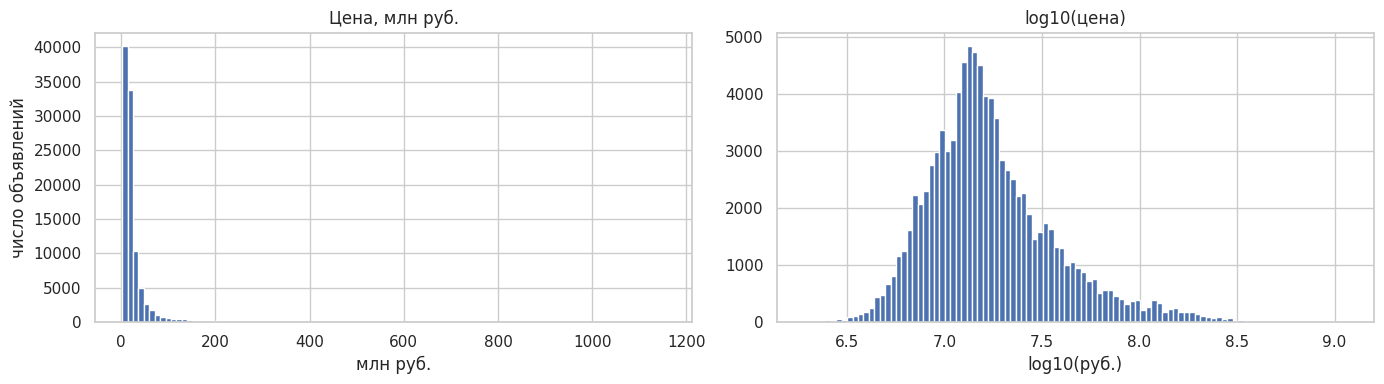

Асимметрия price: 7.5
Асимметрия log(price): 0.96


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(realty["price"] / 1e6, bins=100)
axes[0].set(title="Цена, млн руб.", xlabel="млн руб.", ylabel="число объявлений")
axes[1].hist(np.log10(realty["price"]), bins=100)
axes[1].set(title="log10(цена)", xlabel="log10(руб.)")
plt.tight_layout()
plt.show()

print(f"Асимметрия price: {realty['price'].skew():.1f}")
print(f"Асимметрия log(price): {np.log(realty['price']).skew():.2f}")

**Выводы:** распределение цены имеет очень длинный правый хвост (коэффициент асимметрии ≈ 7,5): медиана 15 млн, но есть квартиры дороже 1 млрд. После логарифмирования асимметрия падает до ≈ 1 — распределение становится близким к нормальному, остаётся умеренный хвост дорогих объектов. Это подтверждает решение обучать модели на `log(price)` и измерять качество относительной метрикой (MAPE).

### 5.2 Цена за квадратный метр

count      98,822.000
mean      334,839.000
std       168,521.000
min       118,865.000
0.1%      120,127.000
1%        129,891.000
50%       292,106.000
99%     1,000,000.000
99.9%   1,193,311.000
max     1,229,728.000
dtype: float64


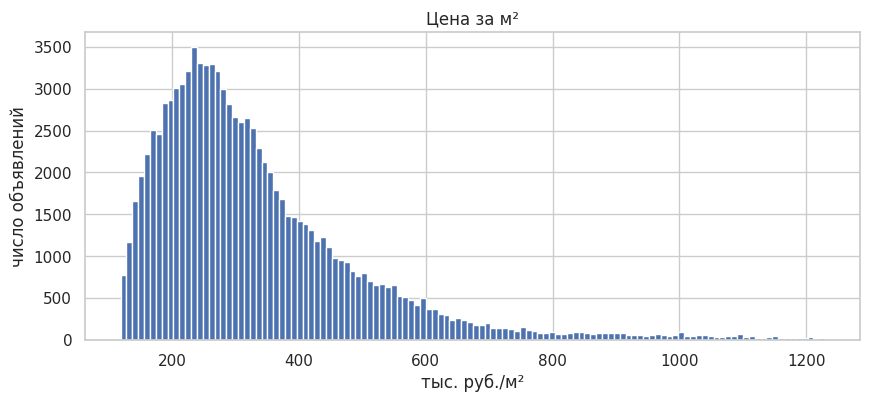

In [9]:
price_per_m2 = realty["price"] / realty["total_square"]
print(price_per_m2.describe(percentiles=[0.001, 0.01, 0.5, 0.99, 0.999]).round(0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(price_per_m2 / 1e3, bins=120)
ax.set(title="Цена за м²", xlabel="тыс. руб./м²", ylabel="число объявлений")
plt.show()

**Выводы:** цена за м² лежит строго в диапазоне ≈ 119 тыс. – 1,23 млн руб., без плавного затухания на краях. Это признак того, что **поставщик данных уже обрезал выбросы** по цене за м² (опечатки в цене, аренду, доли). Дополнительно удалять выбросы по цене не будем: оставшиеся «экстремальные» значения — реальные элитные объекты и дешёвое жильё в дальнем Подмосковье, и модель должна уметь их оценивать.

Практическое следствие для заказчика: модель не видела объектов за пределами этого диапазона цены за м², и для них её оценки будут ненадёжны.

### 5.3 Площадь, комнаты, этаж

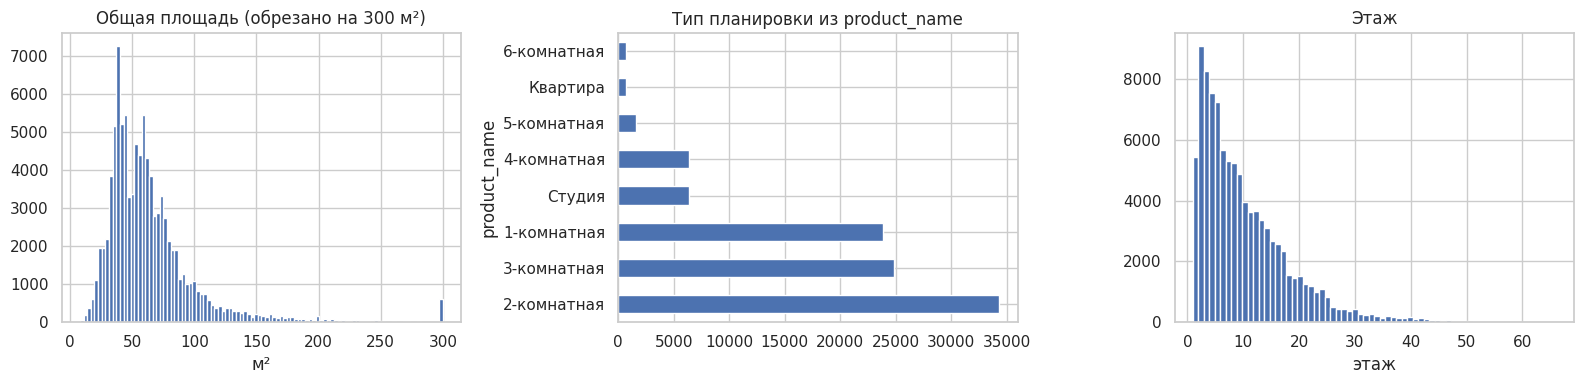

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(realty["total_square"].clip(upper=300), bins=100)
axes[0].set(title="Общая площадь (обрезано на 300 м²)", xlabel="м²")
realty["product_name"].str.split(",").str[0].value_counts().head(8).plot.barh(
    ax=axes[1], title="Тип планировки из product_name"
)
axes[2].hist(realty["floor"], bins=66)
axes[2].set(title="Этаж", xlabel="этаж")
plt.tight_layout()
plt.show()

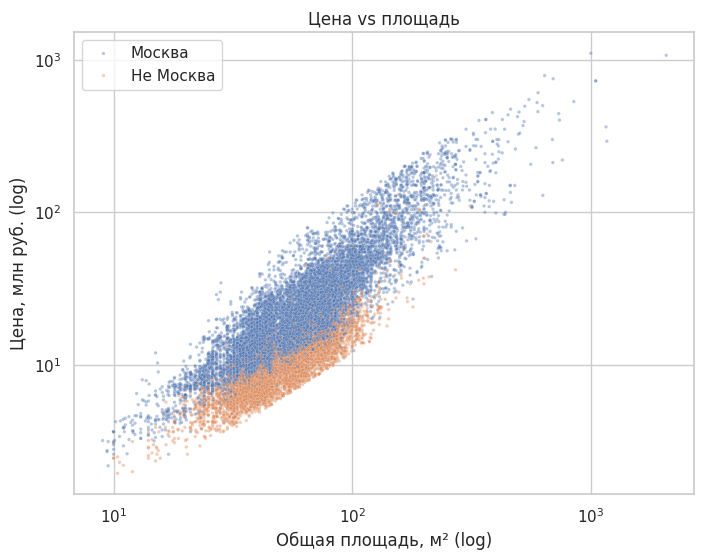

Корреляция Спирмена log(площадь) – log(цена): 0.77


In [11]:
sample = realty.sample(20_000, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=sample["total_square"],
    y=sample["price"] / 1e6,
    hue=np.where(sample["city"] == "Москва", "Москва", "Не Москва"),
    s=6,
    alpha=0.4,
    ax=ax,
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel="Общая площадь, м² (log)",
    ylabel="Цена, млн руб. (log)",
    title="Цена vs площадь",
)
plt.show()

print(
    "Корреляция Спирмена log(площадь) – log(цена): "
    f"{realty['total_square'].corr(realty['price'], method='spearman'):.2f}"
)

**Выводы:**

- Площадь — главный фактор цены: в логарифмических осях зависимость близка к линейной (корреляция Спирмена ≈ 0,8). Для линейной модели площадь стоит логарифмировать.
- При одинаковой площади разброс цены достигает порядка — эту вариацию объясняет местоположение: облако московских квартир лежит заметно выше областных.
- Распределение площади с тяжёлым хвостом (до 2 070 м²), такие объекты единичны.
- `rooms` и площадь сильно связаны, но комнаты несут дополнительную информацию о планировке (площадь на комнату).
- Студии в данных закодированы непоследовательно: у части `rooms` = NaN, у части `rooms` = 1. Приведём студии к `rooms = 0` по `product_name`.
- Этаж скошен вправо (до 66); отдельно этажность дома в данных отсутствует, её можно частично извлечь из текста («17-этажный дом»).

### 5.4 География

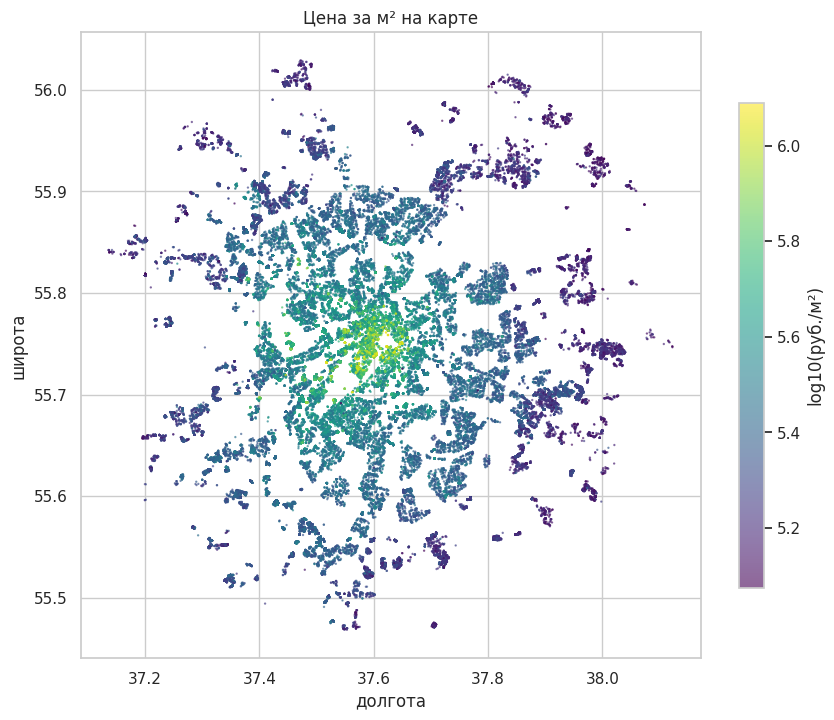

In [12]:
fig, ax = plt.subplots(figsize=(10, 9))
points = ax.scatter(
    realty["lon"],
    realty["lat"],
    c=np.log10(price_per_m2),
    cmap="viridis",
    s=0.5,
    alpha=0.6,
)
ax.set_aspect(1 / np.cos(np.radians(55.75)))
ax.set(title="Цена за м² на карте", xlabel="долгота", ylabel="широта")
colorbar = fig.colorbar(points, ax=ax, shrink=0.7)
colorbar.set_label("log10(руб./м²)")
plt.show()

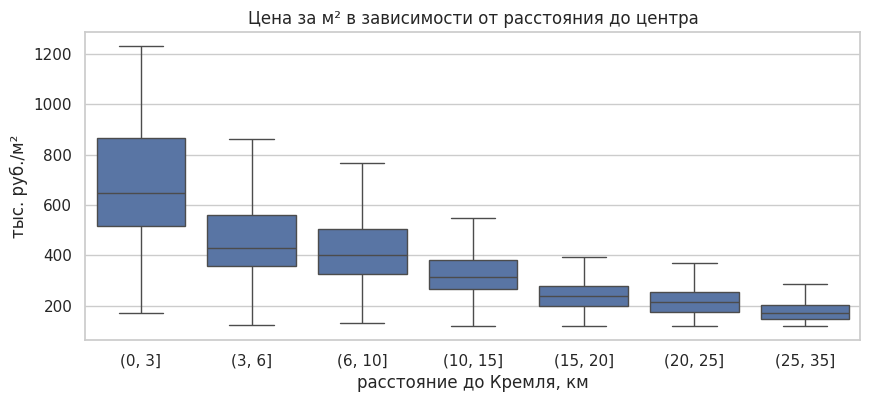

In [13]:
distance_km = haversine_km(realty["lat"], realty["lon"])
distance_bins = pd.cut(distance_km, bins=[0, 3, 6, 10, 15, 20, 25, 35])

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=distance_bins, y=price_per_m2 / 1e3, showfliers=False, ax=ax)
ax.set(
    title="Цена за м² в зависимости от расстояния до центра",
    xlabel="расстояние до Кремля, км",
    ylabel="тыс. руб./м²",
)
plt.show()

**Выводы:**

- На карте хорошо видна кольцевая структура рынка: максимальные цены в центре и на западе (Хамовники, Раменки, Пресня), минимальные — на востоке и юго-востоке области.
- Медианная цена за м² падает с расстоянием до центра монотонно и нелинейно: в пределах 3 км от Кремля медиана ≈ 650 тыс. руб./м², дальше 20 км — в 3–3,5 раза меньше. **Расстояние до центра — сильный признак**; добавим также направление (азимут), чтобы учесть асимметрию «запад дороже востока».
- Сырые `lat`/`lon` линейная модель использовать почти не сможет (зависимость немонотонная), а деревья разобьют карту на участки — это аргумент в пользу бустинга.
- Координаты лежат в пределах Москвы и ближнего Подмосковья, явных ошибок геокодирования (точек за пределами региона) нет.

### 5.5 Категориальные признаки: район, населённый пункт, источник

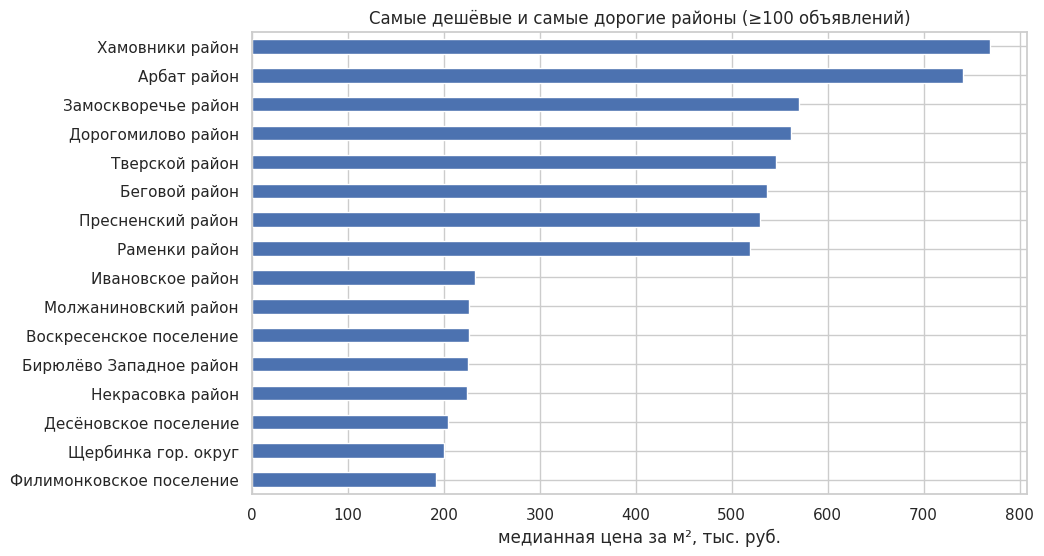

Районов: 130, микрорайонов: 269


In [14]:
district_stats = (
    pd.DataFrame({"district": realty["district"], "price_per_m2": price_per_m2})
    .groupby("district")["price_per_m2"]
    .agg(["median", "size"])
    .query("size >= 100")
    .sort_values("median")
)
extremes = pd.concat([district_stats.head(8), district_stats.tail(8)])

fig, ax = plt.subplots(figsize=(10, 6))
(extremes["median"] / 1e3).plot.barh(ax=ax)
ax.set(
    title="Самые дешёвые и самые дорогие районы (≥100 объявлений)",
    xlabel="медианная цена за м², тыс. руб.",
    ylabel="",
)
plt.show()

print(
    f"Районов: {realty['district'].nunique()}, микрорайонов: {realty['area'].nunique()}"
)

,объявлений,медиана руб./м²,доля Москвы,медиана площади
source,,,,
Домклик,36926,"235,294.118",0.522,45.000
Новострой-М,10909,"326,000.000",0.775,50.000
ЦИАН,42171,"328,822.733",0.869,66.300
Яндекс.Недвижимость,8816,"341,087.838",0.999,51.000


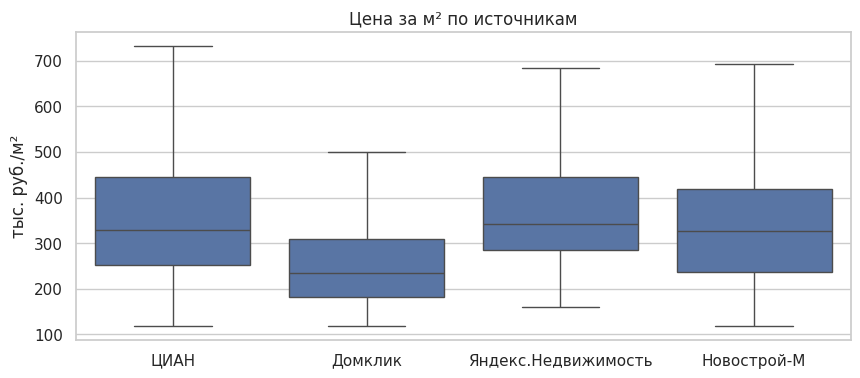

In [15]:
source_stats = pd.DataFrame(
    {
        "объявлений": realty["source"].value_counts(),
        "медиана руб./м²": price_per_m2.groupby(realty["source"]).median(),
        "доля Москвы": (realty["city"] == "Москва").groupby(realty["source"]).mean(),
        "медиана площади": realty.groupby("source")["total_square"].median(),
    }
)
display(source_stats)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x=realty["source"], y=price_per_m2 / 1e3, showfliers=False, ax=ax)
ax.set(title="Цена за м² по источникам", xlabel="", ylabel="тыс. руб./м²")
plt.show()

**Выводы:**

- Медианная цена за м² между районами различается до 4 раз (≈ 190 тыс. в Филимонковском поселении против ≈ 770 тыс. в Хамовниках). Районов 130 — это категориальный признак высокой кардинальности: для линейной модели потребуется one-hot-кодирование с объединением редких категорий, а LightGBM умеет работать с такими категориями напрямую.
- Объявления на **Домклике заметно дешевле** по цене за м², но и доля Москвы там ниже. Разница в источниках частично объясняется географией, а частично — аудиторией площадки. Источник оставим как признак: цену объявления на конкретной площадке он объясняет честно. На этапе интерпретации проверим, не опирается ли на него модель слишком сильно.

### 5.6 Текст объявлений

In [16]:
description = realty["description"].fillna("").str.lower()
text_flag_stats = []
for name, pattern in TEXT_FLAGS.items():
    has_flag = description.str.contains(pattern, regex=True)
    text_flag_stats.append(
        {
            "признак": name,
            "доля объявлений": has_flag.mean(),
            "медиана руб./м² (есть)": price_per_m2[has_flag].median(),
            "медиана руб./м² (нет)": price_per_m2[~has_flag].median(),
        }
    )
text_flag_stats = pd.DataFrame(text_flag_stats).set_index("признак")
text_flag_stats["отношение"] = (
    text_flag_stats["медиана руб./м² (есть)"] / text_flag_stats["медиана руб./м² (нет)"]
)
text_flag_stats.sort_values("отношение")

,доля объявлений,медиана руб./м² (есть),медиана руб./м² (нет),отношение
признак,,,,
is_owner,0.369,"261,476.228","317,552.000",0.823
has_euro_repair,0.023,"264,328.679","292,977.011",0.902
is_no_finish,0.072,"298,602.667","291,666.667",1.024
is_new_building,0.283,"317,000.000","282,894.737",1.121
is_white_box,0.042,"346,000.000","289,000.000",1.197
has_parking,0.253,"340,259.740","276,315.789",1.231
has_view,0.072,"356,299.603","288,452.378",1.235
is_apartments,0.061,"361,363.636","286,842.105",1.260
has_designer_repair,0.090,"365,535.890","286,545.348",1.276


**Выводы:**

- В тексте есть заметный сигнал: упоминание пентхауса или террасы — около +75 % к медианной цене за м², дизайнерского ремонта, апартаментов, видовых характеристик и паркинга — по +20–30 %.
- «Евроремонт» связан с ценой ниже медианы (−10 %): так обычно описывают вторичное жильё среднего сегмента, а не премиальные объекты.
- «Собственник» связан с более низкой ценой за м² — вероятно, это вторичное жильё в спальных районах и области.
- Флаги грубые (регулярные выражения не учитывают отрицания вроде «не апартаменты»), но дёшевы и интерпретируемы. Полноценную обработку текста (TF-IDF, эмбеддинги) оставим как направление развития.
- **Риск утечки:** в тексте иногда написана цена. Числовые значения цены из описания не извлекаем; из чисел берём только время до метро и этажность дома.

### 5.7 Одна квартира на нескольких площадках

In [17]:
listing_groups = make_listing_groups(realty)
group_stats = realty.groupby(listing_groups).agg(
    n=("price", "size"),
    n_sources=("source", "nunique"),
    price_min=("price", "min"),
    price_max=("price", "max"),
)
repeated = group_stats.query("n > 1")
print(f"Квартир, встречающихся более одного раза: {len(repeated):,}")
n_repeated = repeated["n"].sum()
print(f"Объявлений в таких группах: {n_repeated:,} ({n_repeated / len(realty):.1%})")
print(f"Из них размещены на разных площадках: {(repeated['n_sources'] > 1).mean():.0%}")
print(
    "Цена отличается менее чем на 5 %: "
    f"{(repeated['price_max'] / repeated['price_min'] < 1.05).mean():.0%}"
)

Квартир, встречающихся более одного раза: 6,950
Объявлений в таких группах: 15,294 (15.5%)
Из них размещены на разных площадках: 40%
Цена отличается менее чем на 5 %: 72%


**Выводы:** около 15 % объявлений относятся к квартирам (адрес + площадь + этаж), которые встречаются несколько раз — одна квартира на разных площадках или повторная публикация. Цены в таких группах обычно почти совпадают.

Удалять такие объявления не будем (часть групп — действительно разные квартиры в одном доме-новостройке с типовыми планировками). Но **при случайном разбиении копии попадут и в train, и в test**, и модель будет «угадывать» цену по памяти, завышая качество. Поэтому разбиение на выборки и кросс-валидацию делаем **по группам** (`GroupShuffleSplit`, `GroupKFold`).

### 5.8 Корреляции числовых признаков

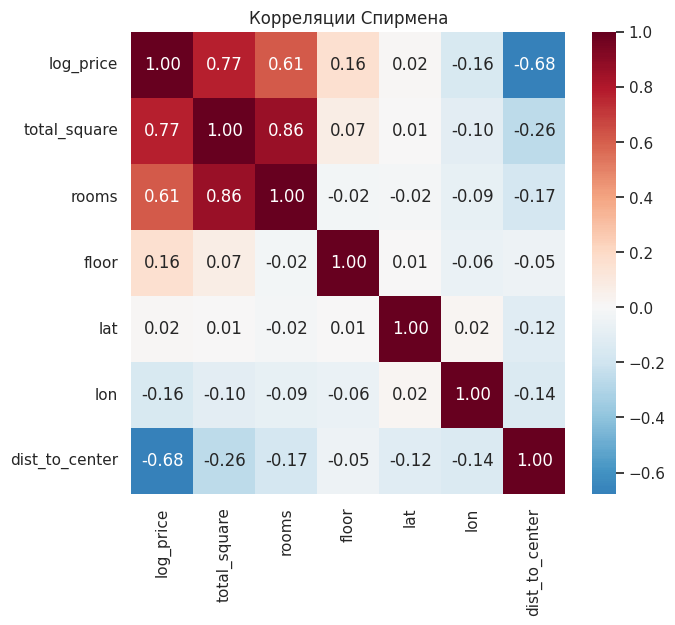

In [18]:
numeric_view = pd.DataFrame(
    {
        "log_price": np.log(realty["price"]),
        "total_square": realty["total_square"],
        "rooms": realty["rooms"],
        "floor": realty["floor"],
        "lat": realty["lat"],
        "lon": realty["lon"],
        "dist_to_center": distance_km,
    }
)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    numeric_view.corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
)
ax.set_title("Корреляции Спирмена")
plt.show()

**Выводы:** с логарифмом цены сильнее всего связаны площадь (+0,77), расстояние до центра (−0,68) и число комнат (+0,61). Отдельно широта и долгота с ценой почти не коррелируют — зависимость от местоположения нелинейная (кольцевая), и её лучше передаёт расстояние до центра. Площадь и комнаты сильно коррелируют между собой (мультиколлинеарность) — для Ridge это не критично благодаря L2-регуляризации, для деревьев не проблема вовсе. Этаж связан с ценой слабо, скорее всего нелинейно (первые этажи дешевле, высокие этажи в элитных домах дороже).

### Итоги EDA и план предобработки

| Проблема / наблюдение | Решение |
|---|---|
| `period` пустой, `object_type` константный | удалить |
| Пропуски `city`, `settlement`, `district`, `area` не случайны | объединить `city`+`settlement` в «населённый пункт», пропуски → категория «нет» |
| Студии закодированы непоследовательно | `rooms = 0` для студий, флаги «студия» и «свободная планировка» |
| Цена сильно скошена, ошибка важна относительно цены | обучение на `log(price)`, метрика MAPE |
| Цена сильно зависит от расстояния до центра и направления | признаки расстояния до Кремля и азимута |
| Сигнал в тексте объявления | бинарные флаги по ключевым словам, время до метро, этажность дома |
| Одна квартира на нескольких площадках | групповое разбиение train/test и групповая кросс-валидация |
| Районы и населённые пункты — высокая кардинальность | one-hot с объединением редких для Ridge, нативные категории для LightGBM |
| Выбросы по цене за м² уже обрезаны поставщиком | дополнительно не чистим, но фиксируем ограничение применимости модели |

## 6. Предобработка и генерация признаков

Функция `build_features` из `helpers.py` реализует план из EDA. Она **не использует целевую переменную и статистики по выборке** (средние, частоты), поэтому её безопасно применять ко всему датасету до разбиения — утечки из test в train не возникает. Всё, что обучается на данных (импутация медианой, масштабирование, кодирование категорий), делается внутри sklearn-пайплайнов только на train.

In [19]:
features = build_features(realty)
target = realty["price"]
groups = make_listing_groups(realty)

print(f"Признаков: {features.shape[1]}")
features.head()

Признаков: 30


,total_square,is_studio,is_free_layout,rooms,square_per_room,floor,house_floors,floor_ratio,lat,lon,dist_to_center_km,bearing_deg,metro_walk_min,is_moscow,address_has_zhk,is_apartments,is_premium,has_designer_repair,has_euro_repair,is_no_finish,is_white_box,has_parking,has_view,is_owner,is_new_building,description_len_log,district,locality,microdistrict,source
0,137.000,0,0,3.000,45.667,6.000,NaN,NaN,55.779,37.609,3.039,100.267,NaN,1,0,0,0,0,0,0,0,1,0,0,0,6.392,Тверской район,Москва,нет,ЦИАН
1,16.700,1,0,0.000,16.700,1.000,NaN,NaN,55.551,37.313,29.398,-130.448,5.000,1,0,0,0,0,0,0,0,0,0,0,0,7.666,Филимонковское поселение,Москва,нет,Домклик
2,76.000,0,0,3.000,25.333,6.000,NaN,NaN,55.595,37.431,21.022,-123.693,8.000,1,1,0,0,0,0,1,0,1,1,0,1,7.703,Сосенское поселение,Москва,нет,Яндекс.Недвижимость
3,24.000,0,0,1.000,24.000,10.000,NaN,NaN,55.594,37.428,21.176,-124.060,NaN,1,1,0,0,0,0,0,0,0,0,0,1,5.905,Сосенское поселение,Москва,нет,Новострой-М
4,126.000,0,0,3.000,42.000,16.000,NaN,NaN,55.721,37.464,10.185,-160.276,NaN,1,0,0,0,0,0,0,0,0,1,0,0,7.702,Фили-Давыдково район,Москва,нет,Домклик


In [20]:
features.isna().mean().loc[lambda share: share > 0].to_frame("доля пропусков")

,доля пропусков
rooms,0.007
square_per_room,0.007
house_floors,0.875
floor_ratio,0.875
metro_walk_min,0.745


Пропуски остались только в признаках, извлечённых из текста (`metro_walk_min`, `house_floors`, `floor_ratio`), и в `rooms` у квартир со свободной планировкой. LightGBM обрабатывает NaN сам (выбирает оптимальное направление в каждом разбиении), для Ridge заполним медианой и добавим индикатор пропуска.

## 7. Разбиение на train / test

- Отложенная выборка — 20 % объявлений.
- Разбиение **групповое** по идентификатору квартиры (см. п. 5.7), чтобы копии одной квартиры не оказались по разные стороны.
- Временное разбиение было бы предпочтительнее (модель применяется к будущим объявлениям), но дат в данных нет.

In [21]:
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(features, target, groups))

X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
y_train, y_test = target.iloc[train_idx], target.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"train: {len(X_train):,}, test: {len(X_test):,}")
common_groups = set(groups_train) & set(groups.iloc[test_idx])
print(f"Общих квартир в train и test: {len(common_groups)}")
print(
    "Медиана цены train / test, млн: "
    f"{y_train.median() / 1e6:.2f} / {y_test.median() / 1e6:.2f}"
)

train: 79,080, test: 19,742
Общих квартир в train и test: 0
Медиана цены train / test, млн: 15.10 / 15.35


Для сравнения посмотрим, сколько было бы утечек при обычном случайном разбиении:

In [22]:
random_train, random_test = next(
    GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE).split(
        features, target, groups=np.arange(len(features))
    )
)
leaked_share = groups.iloc[random_test].isin(set(groups.iloc[random_train])).mean()
print(f"При случайном разбиении у {leaked_share:.1%} объектов теста есть копия в train")

При случайном разбиении у 13.3% объектов теста есть копия в train


Выборки сопоставимы по распределению цены, пересечений по квартирам нет. При случайном разбиении ~13 % тестовых объектов имели бы «подсказку» в train.

Кросс-валидацию при подборе гиперпараметров делаем тоже групповой: `GroupKFold` с перемешиванием, 3 фолда (компромисс между надёжностью оценки и временем: на 80 тыс. объектов 3 фолда дают стабильную оценку, а каждый дополнительный фолд линейно увеличивает время подбора).

In [23]:
cv = GroupKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = {}

## 8. Константная модель

Константное предсказание — нижняя граница качества: любая осмысленная модель должна быть лучше. Сравним две константы:

- **медиана** train — оптимальна для MAE;
- **взвешенная медиана с весами 1/y** — оптимальная константа именно для MAPE (минимизирует сумму |y − c| / y).

In [24]:
median_model = DummyRegressor(strategy="median").fit(X_train, y_train)
results["Константа: медиана"] = regression_report(y_test, median_model.predict(X_test))

mape_constant = mape_optimal_constant(y_train.to_numpy())
results["Константа: оптимум MAPE"] = regression_report(
    y_test, np.full(len(y_test), mape_constant)
)

print(
    f"Медиана: {y_train.median() / 1e6:.2f} млн, "
    f"оптимум MAPE: {mape_constant / 1e6:.2f} млн"
)
pd.DataFrame(results).T

Медиана: 15.10 млн, оптимум MAPE: 10.97 млн


,"MAPE, %","MdAPE, %","Доля ошибок <10%, %","MAE, млн руб.",R2
Константа: медиана,52.275,41.196,13.778,14.926,-0.074
Константа: оптимум MAPE,45.133,40.676,10.890,15.907,-0.147


Константа ошибается в среднем на ~50 %, т.е. практической ценности не имеет. MAPE-оптимальная константа ниже медианы (MAPE сильнее штрафует завышение цены дешёвых квартир), и по MAPE она лучше, хотя проигрывает по MAE — наглядная иллюстрация того, что выбор метрики определяет «правильный» ответ. R² ниже нуля: константа хуже, чем предсказание средним по тесту.

## 9. Бейзлайн: Ridge-регрессия

**Почему Ridge:** простая, быстрая и интерпретируемая модель. L2-регуляризация стабилизирует коэффициенты при коррелированных признаках (площадь, комнаты, площадь на комнату) и большом числе one-hot-столбцов.

**Предобработка внутри пайплайна** (обучается только на train):

- скошенные признаки (площадь, площадь на комнату, расстояние, этаж, этажность) → `log1p`, чтобы зависимость от log-цены стала ближе к линейной;
- пропуски → медиана + индикатор пропуска;
- числовые признаки → `StandardScaler` (без масштабирования штраф Ridge действует на признаки неравномерно);
- категории → one-hot; категории, встречающиеся реже 30 раз, объединяются в «infrequent», неизвестные в тесте тоже попадают в неё;
- таргет → `log`, предсказание → `exp` через `TransformedTargetRegressor`.

In [25]:
log_columns = [
    "total_square",
    "square_per_room",
    "dist_to_center_km",
    "floor",
    "house_floors",
]
linear_columns = [
    column
    for column in features.columns
    if column not in log_columns + CATEGORICAL_FEATURES
]

ridge_preprocessor = ColumnTransformer(
    [
        (
            "log_numeric",
            make_pipeline(
                FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler(),
            ),
            log_columns,
        ),
        (
            "numeric",
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True), StandardScaler()
            ),
            linear_columns,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30),
            CATEGORICAL_FEATURES,
        ),
    ]
)

ridge_model = TransformedTargetRegressor(
    regressor=make_pipeline(ridge_preprocessor, Ridge(alpha=1.0)),
    func=np.log,
    inverse_func=np.exp,
)
ridge_model.fit(X_train, y_train)

results["Ridge (бейзлайн)"] = regression_report(y_test, ridge_model.predict(X_test))
pd.DataFrame(results).T

,"MAPE, %","MdAPE, %","Доля ошибок <10%, %","MAE, млн руб.",R2
Константа: медиана,52.275,41.196,13.778,14.926,-0.074
Константа: оптимум MAPE,45.133,40.676,10.890,15.907,-0.147
Ridge (бейзлайн),13.796,10.602,47.786,4.724,0.864


Бейзлайн сразу снижает MAPE примерно в 3 раза относительно константы. Основное ограничение линейной модели — она не может выучить взаимодействия (например, «площадь × район»: наценка за метр в центре другая, чем в области) и нелинейную географию по сырым координатам. Это ровно то, что умеют ансамбли деревьев.

## 10. Градиентный бустинг: LightGBM

**Почему LightGBM:**

- ансамбль деревьев улавливает нелинейности и взаимодействия признаков, в том числе «разрезает» карту по координатам;
- нативно работает с категориальными признаками высокой кардинальности (130 районов, 270 микрорайонов) без one-hot;
- сам обрабатывает пропуски и не требует масштабирования;
- на ~80 тыс. объектов обучается за секунды, что позволяет провести полноценный подбор гиперпараметров на кросс-валидации.

Модель обучаем, как и Ridge, на `log(price)` через `TransformedTargetRegressor`, поэтому метрика на кросс-валидации считается в рублях.

**Какие гиперпараметры подбираем и почему:**

| Гиперпараметр | Роль |
|---|---|
| `learning_rate`, `n_estimators` | размер шага и число деревьев; подбираются совместно: меньший шаг требует больше деревьев |
| `num_leaves` | сложность дерева — основной регулятор взаимодействий признаков в LightGBM (деревья растут по листьям) |
| `min_child_samples` | минимум объектов в листе; защищает от запоминания единичных дорогих квартир |
| `subsample`, `colsample_bytree` | стохастичность по объектам и признакам, снижает дисперсию ансамбля |
| `reg_lambda` | L2-регуляризация весов листьев |
| `cat_smooth` | сглаживание статистик по редким категориям (редкие районы/посёлки) |

Остальные параметры фиксируем: `deterministic=True` и `force_row_wise=True` — для воспроизводимости, `subsample_freq=1` — чтобы `subsample` действительно применялся.

In [26]:
BASE_LGBM_PARAMS = {
    "objective": "regression",
    "subsample_freq": 1,
    "random_state": RANDOM_STATE,
    "n_jobs": N_JOBS,
    "deterministic": True,
    "force_row_wise": True,
    "verbose": -1,
}


def make_lgbm_model(**params):
    """LightGBM на log(price) с обратным преобразованием предсказаний."""
    return TransformedTargetRegressor(
        regressor=lgb.LGBMRegressor(**BASE_LGBM_PARAMS, **params),
        func=np.log,
        inverse_func=np.exp,
    )


def cv_mape(model):
    """MAPE (%) на групповой кросс-валидации по train."""
    scores = cross_validate(
        model,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv,
        scoring="neg_mean_absolute_percentage_error",
    )
    return -100 * scores["test_score"].mean()

### 10.1 Точка отсчёта: LightGBM с параметрами по умолчанию

In [27]:
default_cv_mape = cv_mape(make_lgbm_model())
print(f"LightGBM по умолчанию, MAPE на CV: {default_cv_mape:.2f} %")

LightGBM по умолчанию, MAPE на CV: 10.60 %


### 10.2 Подбор гиперпараметров: `RandomizedSearchCV` (scikit-learn)

Используем случайный поиск, а не `GridSearchCV`: при 8 гиперпараметрах сетка даже по 3 значения — это 6 561 комбинация. Случайный поиск при том же бюджете проверяет больше разных значений каждого параметра. Для `learning_rate` и `reg_lambda` берём лог-равномерные распределения, так как важен порядок величины.

In [28]:
random_search_space = {
    "regressor__learning_rate": loguniform(0.02, 0.2),
    "regressor__n_estimators": randint(200, 1000),
    "regressor__num_leaves": randint(15, 128),
    "regressor__min_child_samples": randint(5, 100),
    "regressor__subsample": uniform(0.6, 0.4),
    "regressor__colsample_bytree": uniform(0.4, 0.6),
    "regressor__reg_lambda": loguniform(1e-3, 10),
    "regressor__cat_smooth": uniform(1, 49),
}

random_search = RandomizedSearchCV(
    make_lgbm_model(),
    param_distributions=random_search_space,
    n_iter=N_ITER_RANDOM_SEARCH,
    scoring="neg_mean_absolute_percentage_error",
    cv=cv,
    refit=False,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
random_search.fit(X_train, y_train, groups=groups_train)

random_search_best_params = {
    name.removeprefix("regressor__"): value.item() if hasattr(value, "item") else value
    for name, value in random_search.best_params_.items()
}
random_search_cv_mape = -100 * random_search.best_score_
print(f"RandomizedSearchCV, лучший MAPE на CV: {random_search_cv_mape:.2f} %")
random_search_best_params

RandomizedSearchCV, лучший MAPE на CV: 8.76 %


{'cat_smooth': 10.743277800351454,
 'colsample_bytree': 0.82680517164919,
 'learning_rate': 0.12336885561856077,
 'min_child_samples': 9,
 'n_estimators': 689,
 'num_leaves': 117,
 'reg_lambda': 0.4020759548749851,
 'subsample': 0.9659838702175123}

In [29]:
(
    pd.DataFrame(random_search.cv_results_)
    .assign(cv_mape=lambda frame: -100 * frame["mean_test_score"])
    .sort_values("cv_mape")
    .filter(regex="param_|cv_mape|mean_fit_time")
    .head()
)

,mean_fit_time,param_regressor__cat_smooth,param_regressor__colsample_bytree,param_regressor__learning_rate,param_regressor__min_child_samples,param_regressor__n_estimators,param_regressor__num_leaves,param_regressor__reg_lambda,param_regressor__subsample,cv_mape
11,4.501,10.743,0.827,0.123,9,689,117,0.402,0.966,8.765
8,4.551,44.847,0.759,0.167,76,661,101,0.121,0.984,8.975
9,3.187,42.382,0.848,0.069,28,416,74,0.148,0.656,9.296
3,8.318,26.714,0.640,0.022,64,982,76,0.002,0.847,9.314
1,6.619,23.503,0.600,0.028,7,861,67,7.579,0.933,9.333


### 10.3 Подбор гиперпараметров: Optuna

Optuna использует **TPE** (Tree-structured Parzen Estimator) — байесовский подход: следующие наборы параметров выбираются с учётом того, какие области пространства уже показали хорошее качество. Это эффективнее случайного поиска при том же числе обучений.

Решения:

- то же пространство поиска, что и в `RandomizedSearchCV`, — для честного сравнения;
- `TPESampler(seed=RANDOM_STATE)` — воспроизводимость;
- **pruning** (`MedianPruner`): после каждого фолда промежуточный MAPE сообщается Optuna, и заведомо плохие наборы останавливаются, не дожидаясь всех фолдов — экономит время;
- лучший набор из `RandomizedSearchCV` ставится в очередь первым испытанием (`enqueue_trial`): Optuna продолжает поиск от уже найденной хорошей точки, а не с нуля.

In [30]:
def objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        "cat_smooth": trial.suggest_float("cat_smooth", 1, 50),
    }
    fold_scores = []
    folds = cv.split(X_train, y_train, groups_train)
    for fold, (fit_idx, valid_idx) in enumerate(folds):
        model = make_lgbm_model(**params)
        model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prediction = model.predict(X_train.iloc[valid_idx])
        fold_scores.append(
            100 * mean_absolute_percentage_error(y_train.iloc[valid_idx], prediction)
        )
        trial.report(np.mean(fold_scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)


study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
    study_name="lgbm_realty_price",
)
study.enqueue_trial(random_search_best_params)
study.optimize(objective, n_trials=N_TRIALS_OPTUNA)

n_pruned = sum(trial.state == optuna.trial.TrialState.PRUNED for trial in study.trials)
print(f"Испытаний: {len(study.trials)}, остановлено pruner-ом: {n_pruned}")
print(f"Optuna, лучший MAPE на CV: {study.best_value:.2f} %")
study.best_params

Испытаний: 25, остановлено pruner-ом: 7
Optuna, лучший MAPE на CV: 8.76 %


{'learning_rate': 0.11318544291915471,
 'n_estimators': 753,
 'num_leaves': 124,
 'min_child_samples': 17,
 'subsample': 0.9534111686850967,
 'colsample_bytree': 0.9127502923113789,
 'reg_lambda': 0.9176051818535447,
 'cat_smooth': 27.651052327803196}

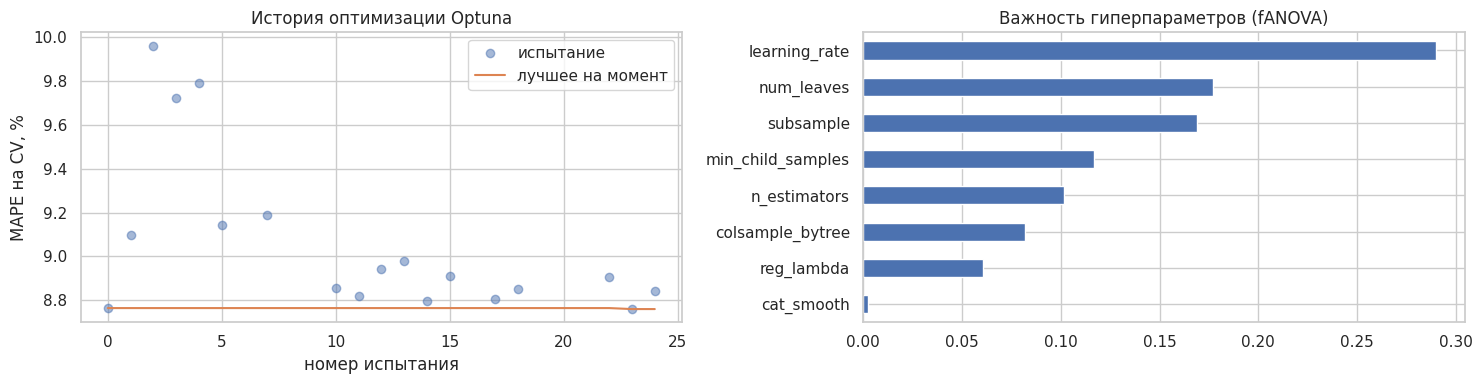

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
history = study.trials_dataframe().query("state == 'COMPLETE'")
axes[0].plot(history["number"], history["value"], "o", alpha=0.5, label="испытание")
axes[0].plot(
    history["number"], history["value"].cummin(), "-", label="лучшее на момент"
)
axes[0].set(
    title="История оптимизации Optuna", xlabel="номер испытания", ylabel="MAPE на CV, %"
)
axes[0].legend()

param_importance = pd.Series(optuna.importance.get_param_importances(study))
param_importance.sort_values().plot.barh(
    ax=axes[1], title="Важность гиперпараметров (fANOVA)"
)
plt.tight_layout()
plt.show()

### 10.4 Финальная модель и качество на отложенной выборке

Выбираем лучший набор гиперпараметров по MAPE на кросс-валидации (не по тесту — тест используется один раз для финальной оценки), обучаем модель на всём train и измеряем качество на test.

In [32]:
tuning_summary = pd.Series(
    {
        "LightGBM по умолчанию": default_cv_mape,
        "RandomizedSearchCV": random_search_cv_mape,
        "Optuna": study.best_value,
    },
    name="MAPE на CV, %",
)
display(tuning_summary.to_frame())

best_params = (
    study.best_params
    if study.best_value <= random_search_cv_mape
    else random_search_best_params
)
final_model = make_lgbm_model(**best_params)
final_model.fit(X_train, y_train)
test_prediction = final_model.predict(X_test)

results["LightGBM (подобранный)"] = regression_report(y_test, test_prediction)
results_table = pd.DataFrame(results).T
results_table

,"MAPE на CV, %"
LightGBM по умолчанию,10.595
RandomizedSearchCV,8.765
Optuna,8.760


,"MAPE, %","MdAPE, %","Доля ошибок <10%, %","MAE, млн руб.",R2
Константа: медиана,52.275,41.196,13.778,14.926,-0.074
Константа: оптимум MAPE,45.133,40.676,10.890,15.907,-0.147
Ridge (бейзлайн),13.796,10.602,47.786,4.724,0.864
LightGBM (подобранный),8.450,5.648,70.054,2.840,0.912


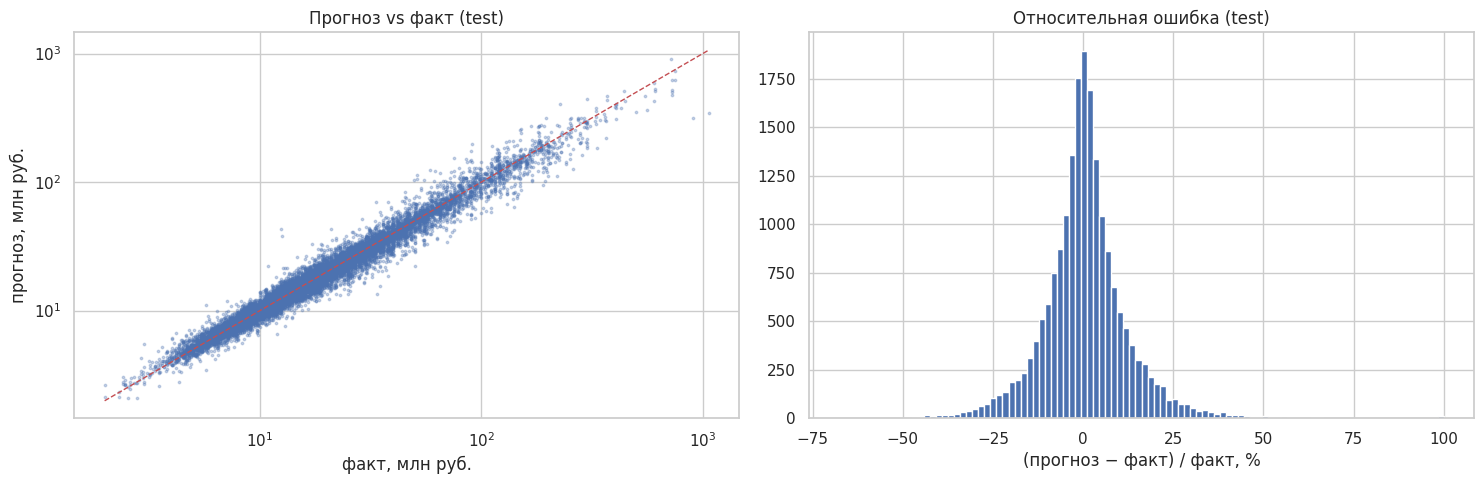

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(y_test / 1e6, test_prediction / 1e6, s=3, alpha=0.3)
limits = [y_test.min() / 1e6, y_test.max() / 1e6]
axes[0].plot(limits, limits, "r--", linewidth=1)
axes[0].set(
    xscale="log",
    yscale="log",
    xlabel="факт, млн руб.",
    ylabel="прогноз, млн руб.",
    title="Прогноз vs факт (test)",
)
relative_error = (test_prediction - y_test) / y_test
axes[1].hist(100 * relative_error.clip(-1, 1), bins=100)
axes[1].set(title="Относительная ошибка (test)", xlabel="(прогноз − факт) / факт, %")
plt.tight_layout()
plt.show()

Посмотрим, где модель ошибается сильнее — это важно для заказчика, чтобы понимать границы применимости.

In [34]:
test_analysis = pd.DataFrame(
    {
        "ape": 100 * relative_error.abs(),
        "Регион": np.where(X_test["is_moscow"] == 1, "Москва", "Не Москва"),
        "Ценовой сегмент": pd.qcut(
            y_test, q=4, labels=["до Q1", "Q1–Q2", "Q2–Q3", "выше Q3"]
        ),
        "Источник": X_test["source"],
    }
)
segment_tables = [
    test_analysis.groupby(column, observed=True)["ape"]
    .agg(MAPE="mean", MdAPE="median", n="size")
    .rename_axis(index=None)
    .assign(срез=column)
    for column in ["Регион", "Ценовой сегмент", "Источник"]
]
pd.concat(segment_tables).set_index("срез", append=True).swaplevel()

MAPE  MdAPE      n
срез                                                    
Регион          Москва               8.512  5.383  14601
                Не Москва            8.275  6.275   5141
Ценовой сегмент до Q1                7.187  5.084   4991
                Q1–Q2                7.296  5.096   4881
                Q2–Q3                7.917  5.286   4943
                выше Q3             11.408  7.519   4927
Источник        Домклик              9.459  7.172   7381
                Новострой-М          3.915  2.593   2170
                ЦИАН                 9.796  6.686   8481
                Яндекс.Недвижимость  3.178  2.278   1710

**Выводы по моделированию**

- Подбор гиперпараметров снизил MAPE на кросс-валидации с 10,6 % (LightGBM по умолчанию) до 8,76 %. `RandomizedSearchCV` и Optuna пришли к близкому качеству (8,765 % и 8,760 %), и оба лучших набора похожи: `learning_rate` ≈ 0,11–0,12, `n_estimators` ≈ 700, много листьев (117–124), слабая регуляризация. Optuna почти не улучшила результат случайного поиска: качество вышло на плато, и дальнейший выигрыш стоит искать в признаках, а не в гиперпараметрах. По fANOVA сильнее всего на качество влияют `learning_rate`, `num_leaves` и `subsample`, а `cat_smooth` почти не влияет.
- Оптимальное `num_leaves` оказалось у верхней границы диапазона (127), который сужен ради времени расчёта. Расширение диапазона может дать небольшой дополнительный выигрыш.
- **На отложенной выборке: MAPE 8,45 %, MdAPE 5,6 %, у 70 % объявлений ошибка меньше 10 %, R² = 0,91.** Это заметно лучше Ridge (MAPE 13,8 %, ошибка < 10 % у 48 % объявлений) и константы (45–52 %). Качество на test согласуется с кросс-валидацией, признаков переобучения на подборе нет.
- **Где модель ошибается сильнее:**
  - дорогой сегмент (верхний квартиль цены): MAPE 11,4 % против 7–8 % в остальных. Элитных объектов мало, и их цена сильнее зависит от характеристик, которых нет в данных (класс дома, вид, конкретный ЖК);
  - по источникам разница очень большая: Новострой-М и Яндекс.Недвижимость — 3–4 %, ЦИАН и Домклик — около 10 %. Объявления Новострой-М на 100 % относятся к новостройкам от застройщиков: в одном доме продаются десятки однотипных квартир по прайс-листу, и у каждого тестового объекта этих площадок есть квартиры из того же дома в train. Вторичный рынок на ЦИАН и Домклике разнороднее. Для заказчика это значит, что **новостройки модель оценивает очень точно, а вторичное жильё — с типичной ошибкой около 10 %**;
  - Москва и область оцениваются примерно одинаково (MAPE 8,5 % и 8,3 %).

## 11. Интерпретация модели

Используем два независимых метода:

- **SHAP** (TreeExplainer) — точные вклады признаков для деревьев; дают и глобальную, и локальную картину. Модель обучена на `log(price)`, поэтому вклад признака *s* в логарифмических единицах означает, что признак **умножает цену на exp(s)**: например, +0,2 ≈ +22 %, −0,1 ≈ −10 %.
- **Permutation importance** на test — модель-агностичный метод: насколько вырастет MAPE, если перемешать значения признака. В отличие от встроенной `feature_importance` LightGBM, не завышает важность признаков с большим числом уникальных значений и считается в нашей бизнес-метрике.

In [35]:
lgbm_regressor = final_model.regressor_
explainer = shap.TreeExplainer(lgbm_regressor)

shap_sample = X_test.sample(2_000, random_state=RANDOM_STATE)
raw_explanation = explainer(shap_sample)
shap_explanation = shap.Explanation(
    values=raw_explanation.values,
    base_values=raw_explanation.base_values,
    data=categories_to_codes(shap_sample).to_numpy(),
    display_data=shap_sample.to_numpy(),
    feature_names=list(shap_sample.columns),
)
print(
    f"Базовое значение модели: exp({shap_explanation.base_values[0]:.3f}) = "
    f"{np.exp(shap_explanation.base_values[0]) / 1e6:.1f} млн руб."
)

Базовое значение модели: exp(16.661) = 17.2 млн руб.


### 11.1 Глобальная интерпретация

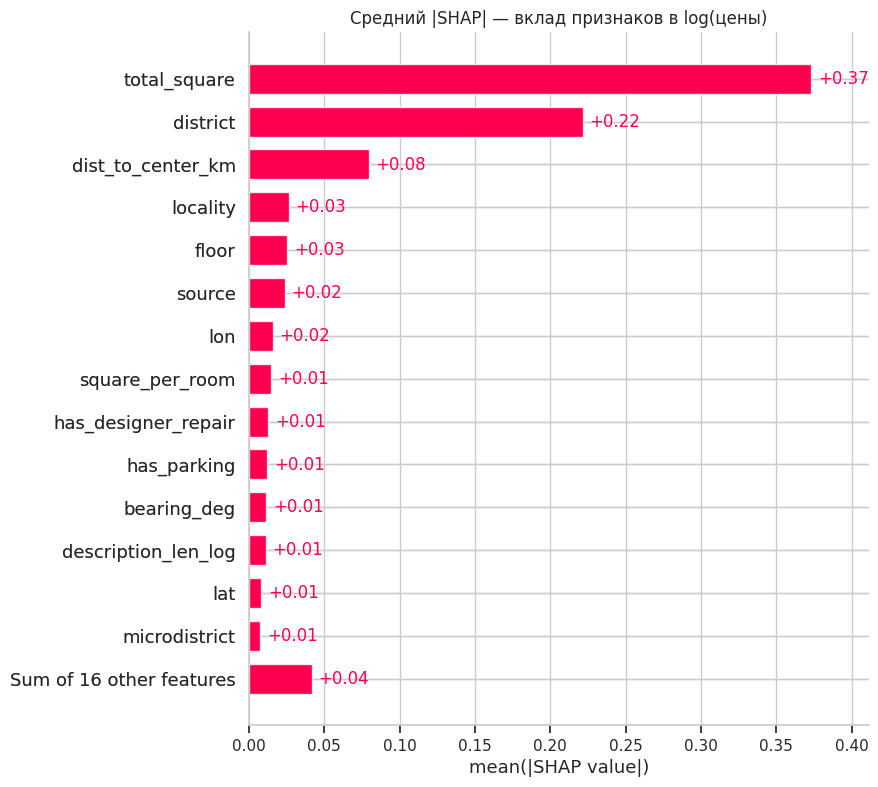

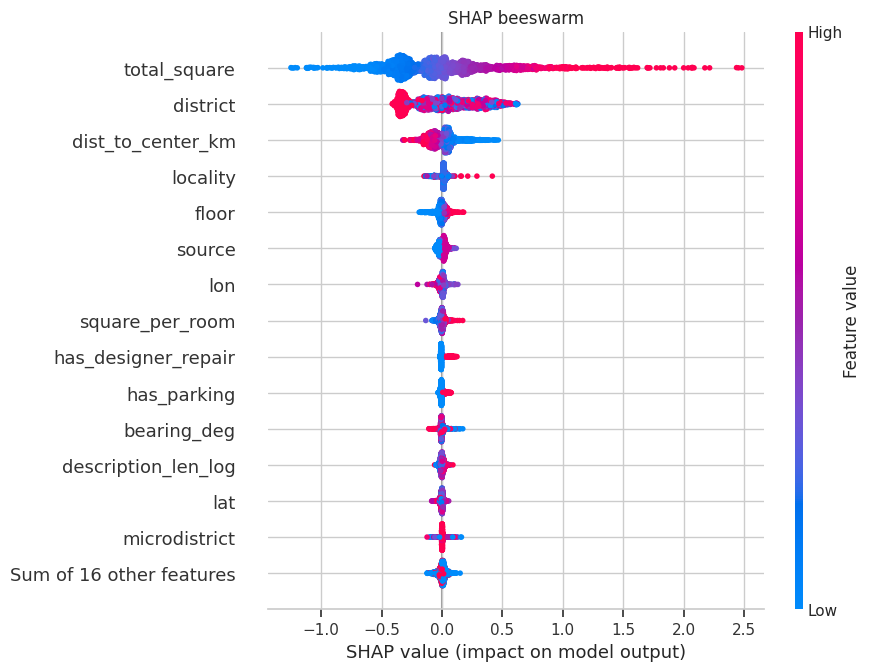

In [36]:
shap.plots.bar(shap_explanation, max_display=15, show=False)
plt.title("Средний |SHAP| — вклад признаков в log(цены)")
plt.show()

shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("SHAP beeswarm")
plt.show()

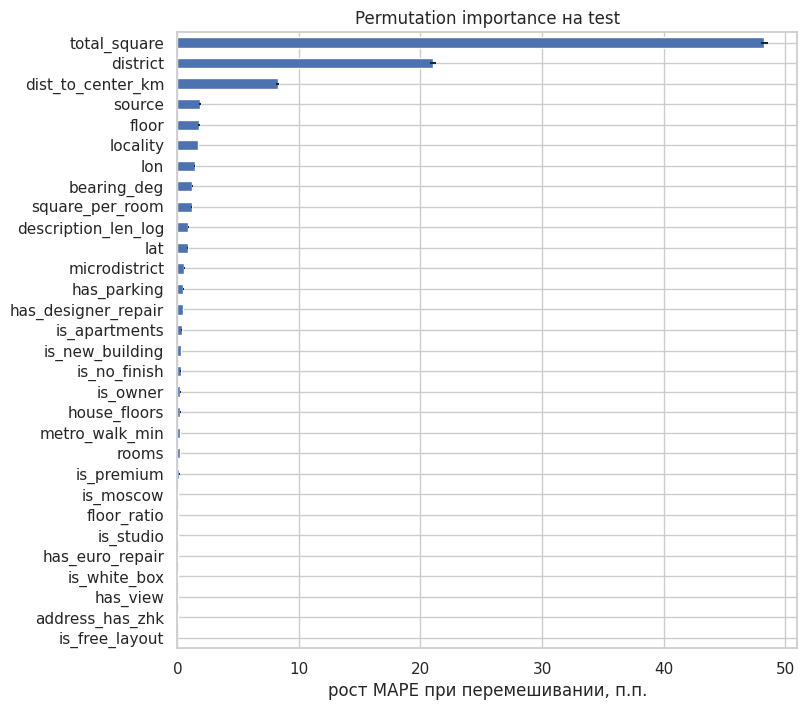

In [37]:
permutation_sample = X_test.sample(5_000, random_state=RANDOM_STATE)
permutation = permutation_importance(
    final_model,
    permutation_sample,
    y_test.loc[permutation_sample.index],
    scoring="neg_mean_absolute_percentage_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
permutation_table = pd.DataFrame(
    {
        "рост MAPE, п.п.": 100 * permutation.importances_mean,
        "std": 100 * permutation.importances_std,
    },
    index=X_test.columns,
).sort_values("рост MAPE, п.п.")

fig, ax = plt.subplots(figsize=(8, 8))
permutation_table["рост MAPE, п.п."].plot.barh(xerr=permutation_table["std"], ax=ax)
ax.set(
    title="Permutation importance на test", xlabel="рост MAPE при перемешивании, п.п."
)
plt.show()

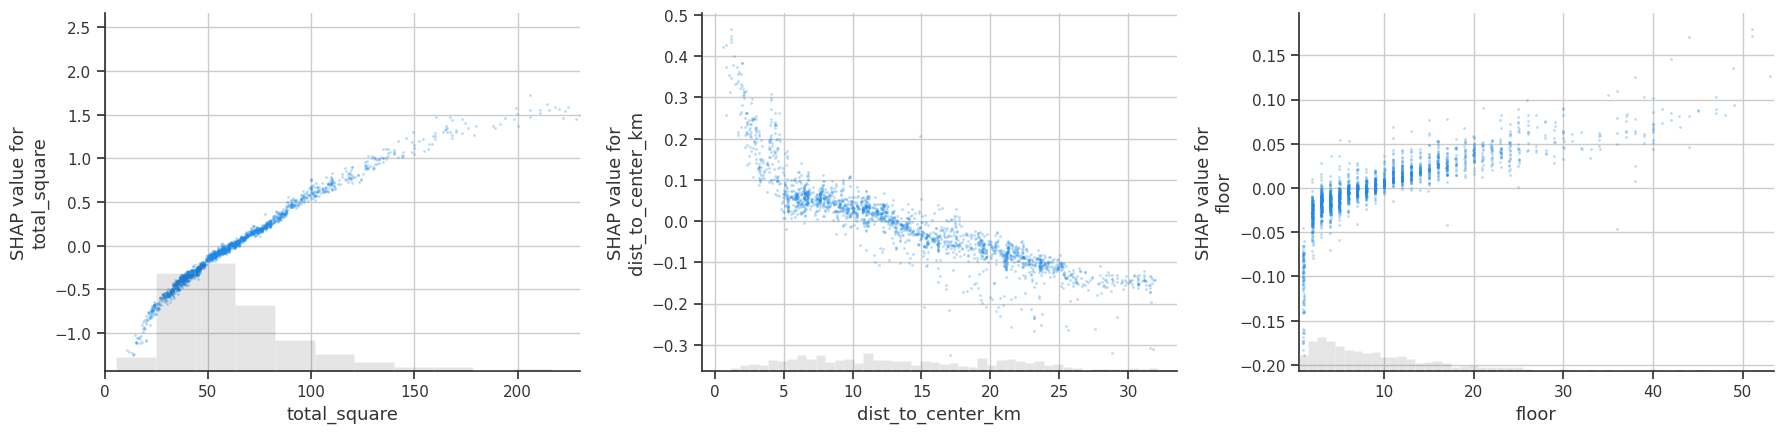

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, feature in zip(axes, ["total_square", "dist_to_center_km", "floor"]):
    shap.plots.scatter(
        shap_explanation[:, feature], ax=ax, show=False, alpha=0.3, dot_size=4
    )
axes[0].set_xlim(0, shap_sample["total_square"].quantile(0.99))
plt.tight_layout()
plt.show()

**Экспертная оценка глобальной интерпретации**

- **Площадь** — главный фактор, что ожидаемо: модель предсказывает полную цену, а не цену за м². **Район** и **расстояние до центра** — второй и третий по важности, и оба метода (SHAP и permutation importance) дают одинаковую тройку лидеров. Это соответствует тому, как ценообразование устроено на рынке: цена ≈ площадь × цена метра в данной локации.
- Зависимость от расстояния до центра выглядит реалистично: внутри ~5 км (Садовое кольцо и ТТК) цена резко растёт — до +40–50 %, между 5 и 12 км есть «полка», далее цена плавно снижается до −15 % на окраинах области.
- Этаж: первый этаж даёт скидку около 10–15 %, с ростом этажа появляется небольшая надбавка до +5–10 % на высоких этажах. Это совпадает с рыночной практикой (дисконт на первые этажи, премия за высотность и виды).
- Текстовые признаки (дизайнерский ремонт, паркинг, апартаменты) дают разумные по знаку, но небольшие по совокупному вкладу эффекты. Часть флагов (`has_view`, `is_white_box`, `address_has_zhk`, `is_moscow`) практически не используется — их информацию уже покрывают район, населённый пункт и координаты. Такие признаки можно удалить без потери качества.
- Настораживает умеренная, но заметная важность **источника** (4-е место в permutation importance): при прочих равных объявление на Домклике оценивается ниже. Статистически это честный признак (площадки различаются аудиторией и сегментом), но для системы ценообразования логичнее, чтобы оценка квартиры не зависела от площадки. Рекомендация: в продуктивной версии либо убрать `source`, либо фиксировать его одним значением при расчёте «справедливой» цены.
- Признаков, которые выглядели бы как утечка целевой переменной, среди важных нет.

### 11.2 Локальная интерпретация

Разберём три объекта из теста: типичную квартиру (медианная цена), дорогую квартиру и объект, на котором модель ошиблась сильнее всего среди подвыборки.

In [39]:
sample_prediction = final_model.predict(shap_sample)
sample_error = (sample_prediction - y_test.loc[shap_sample.index]) / y_test.loc[
    shap_sample.index
]
sample_prices = y_test.loc[shap_sample.index]

prices_array = sample_prices.to_numpy()
selected_objects = {
    "Типичная квартира": int(np.argmin(np.abs(prices_array - sample_prices.median()))),
    "Дорогая квартира": int(
        np.argmin(np.abs(prices_array - sample_prices.quantile(0.99)))
    ),
    "Наибольшая ошибка": int(np.argmax(sample_error.abs().to_numpy())),
}

for title, position in selected_objects.items():
    listing = realty.loc[shap_sample.index[position]]
    actual = listing["price"] / 1e6
    predicted = sample_prediction[position] / 1e6
    print(
        f"{title}: {listing['product_name']}, {listing['address_name']} "
        f"({listing['source']})\n"
        f"  факт {actual:.1f} млн, прогноз {predicted:.1f} млн, "
        f"ошибка {100 * sample_error.iloc[position]:+.0f} %"
    )

Типичная квартира: 2-комнатная, 51 м², Саларьевская, 16 к2 (Домклик)
  факт 15.5 млн, прогноз 13.9 млн, ошибка -10 %
Дорогая квартира: 6-комнатная, 350 м², Новослободская, 11 (ЦИАН)
  факт 150.0 млн, прогноз 253.5 млн, ошибка +69 %
Наибольшая ошибка: 4-комнатная, 167 м², Мытная, 40 к4 (ЦИАН)
  факт 58.5 млн, прогноз 124.8 млн, ошибка +114 %


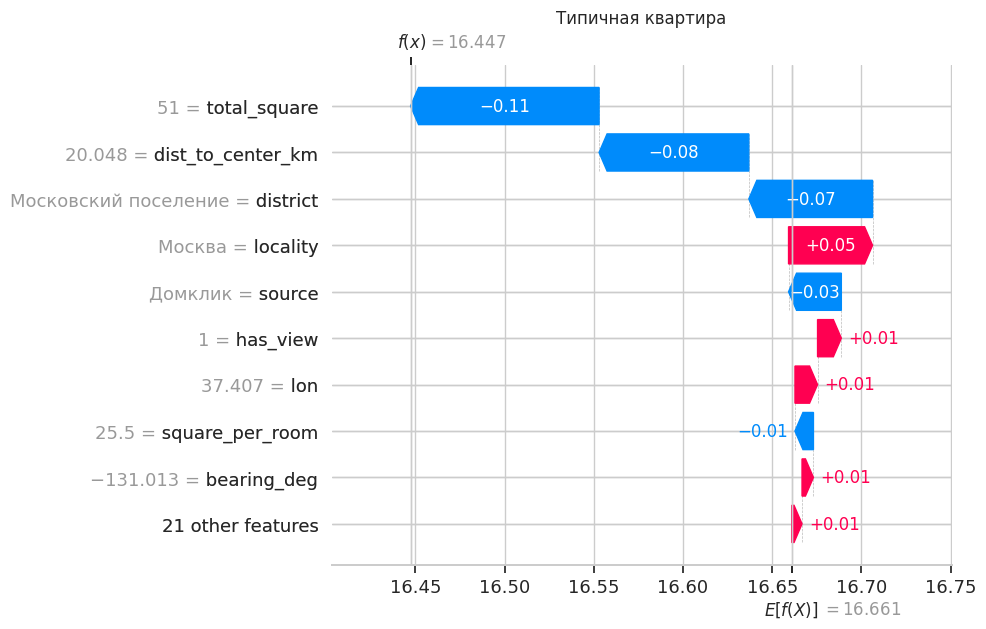

,признак,значение,shap (log),"влияние на цену, %"
0,total_square,51.000,-0.106,-10.026
1,dist_to_center_km,20.048,-0.084,-8.050
2,district,Московский поселение,-0.069,-6.700
3,locality,Москва,0.047,4.822
4,source,Домклик,-0.030,-2.915
5,has_view,1,0.013,1.342
6,lon,37.407,0.013,1.274
7,square_per_room,25.500,-0.010,-1.030


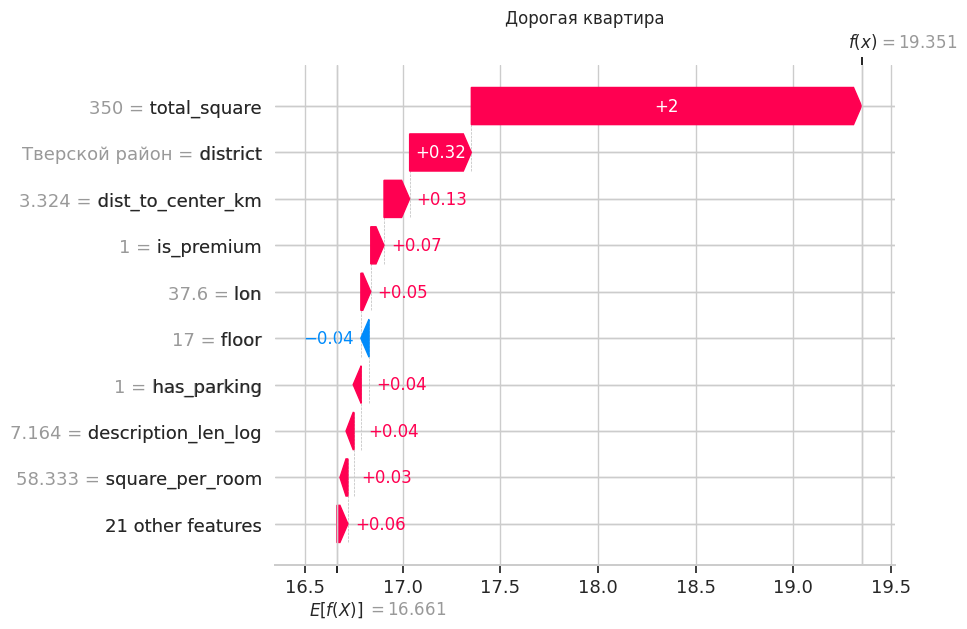

,признак,значение,shap (log),"влияние на цену, %"
0,total_square,350.000,2.000,639.126
1,district,Тверской район,0.316,37.211
2,dist_to_center_km,3.324,0.131,14.039
3,is_premium,1,0.068,7.021
4,lon,37.600,0.051,5.213
5,floor,17.000,-0.042,-4.125
6,has_parking,1,0.040,4.129
7,description_len_log,7.164,0.037,3.734


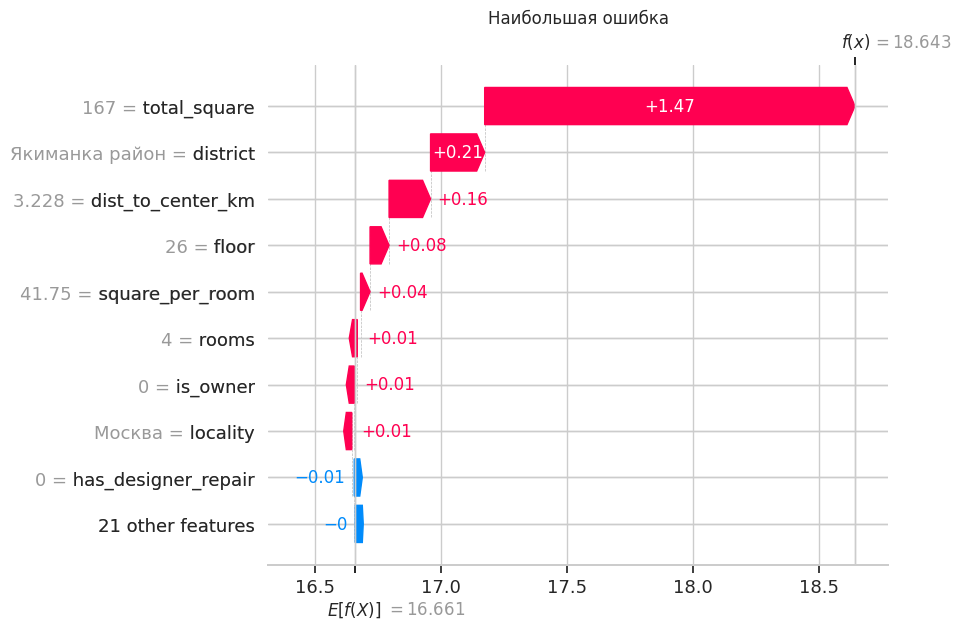

,признак,значение,shap (log),"влияние на цену, %"
0,total_square,167.000,1.468,334.201
1,district,Якиманка район,0.215,23.935
2,dist_to_center_km,3.228,0.164,17.880
3,floor,26.000,0.075,7.835
4,square_per_room,41.750,0.038,3.842
5,rooms,4.000,0.013,1.308
6,is_owner,0,0.012,1.172
7,locality,Москва,0.010,1.036


In [40]:
for title, position in selected_objects.items():
    shap.plots.waterfall(shap_explanation[position], max_display=10, show=False)
    plt.title(title)
    plt.show()
    display(shap_contribution_table(shap_explanation[position]))

In [41]:
worst_index = shap_sample.index[selected_objects["Наибольшая ошибка"]]
print(realty.loc[worst_index, "description"][:1500])

Id 6830. Одно из лучших предложений в ЖК. Видовый 26-й этаж! Виды на Кремль! Sky House расположен на Мытной улице, в историческом центре Москвы в районе Якиманка. Превосходная транспортная доступность. Прекрасно развитая инфраструктура района: МФЦ, дет. сады, школы, ВУЗы, поликлиники, больницы, магазины, рестораны, фитнес, музеи. Сделка будет проходить в виде уступки права требования.
Подходит под ипотеку с господдержкой!
Покупателю, сопровождение сделки - в подарок!
Дополнительная информация по телефону, звоните!


**Экспертная оценка локальной интерпретации**

- **Типичная квартира** (2-комнатная, 51 м², Новая Москва): модель занизила цену на 10 %. Объяснение логично: небольшая площадь, 20 км от центра и поселение Московский дают каждое −7–10 % к базовой цене (17 млн), а принадлежность к городу Москве добавляет около +5 %.
- **Дорогая квартира** (6-комнатная, 350 м², Тверской район) и **объект с наибольшей ошибкой** (4-комнатная, 167 м², ЖК Sky House на Мытной улице, Якиманка) показывают одно и то же системное ограничение. В обоих случаях основную наценку дают площадь и престижный центральный район (+24–37 %), и модель завышает цену на 69 % и 114 % соответственно.
- Проверка по данным показывает, что цена второго объекта **не ошибка в объявлении**. В датасете 180 объявлений из этого дома, и их медиана — около 390 тыс. руб./м². Объект стоит 350 тыс. руб./м², то есть в рамках своего дома, а модель оценила его в ≈ 750 тыс. руб./м², как «типичную» большую квартиру в Якиманке. Модель знает цену метра в районе, но не знает, что конкретный дом дешевле района. Координаты формально есть, но при таком количестве деревьев модель не выделяет отдельные дома.
- **Вывод и направление развития:** главный источник крупных ошибок — отсутствие признаков уровня дома (класс, год постройки, тип дома) и того, что дом может отличаться от района. Самое эффективное улучшение — добавить **медианную цену за м² ближайших соседей или того же дома**, считая её out-of-fold (только по train и без самого объекта), чтобы не допустить утечки таргета.

## 12. Итоги для заказчика

**Что сделано.** По ~99 тыс. объявлений о продаже квартир в Москве и МО построена модель LightGBM, предсказывающая цену объявления. Модель использует площадь, планировку, этаж, местоположение (район, населённый пункт, расстояние и направление от центра) и признаки, извлечённые из текста объявления.

**Качество на отложенной выборке**

| Модель | MAPE | Ошибка < 10 % | R² |
|---|---|---|---|
| Константа (оптимум MAPE) | 45,1 % | 11 % | < 0 |
| Ridge-регрессия (бейзлайн) | 13,8 % | 48 % | 0,86 |
| **LightGBM с подобранными гиперпараметрами** | **8,5 %** | **70 %** | **0,91** |

Типичная (медианная) ошибка модели — 5,6 % цены. Для квартиры за 15 млн это около ±0,8 млн руб.

**Как модель формирует цену.** Цена определяется в первую очередь площадью, затем районом и удалённостью от центра. Меньший, но заметный вклад дают этаж (скидка на первый этаж), дизайнерский ремонт и паркинг. Логика модели совпадает с рыночной, признаков утечки не обнаружено.

**Ограничения, о которых нужно знать**

1. Модель предсказывает **цену предложения**, а не цену сделки.
2. В данных нет дат, поэтому модель отражает рынок на момент выгрузки и **требует регулярного переобучения**.
3. Модель обучена на объектах с ценой 119 тыс. – 1,23 млн руб./м². За пределами этого диапазона оценки ненадёжны.
4. Точность различается по сегментам: новостройки от застройщиков — ошибка 3–4 %, вторичное жильё — около 10 %, элитный сегмент — 11 % и более с отдельными крупными промахами. Для дорогих объектов модель стоит использовать только как ориентир для оценщика.
5. Модель частично опирается на площадку размещения. Для «справедливой» оценки её влияние стоит исключить.

**Рекомендации по развитию**

- добавить признаки уровня дома: цену за м² соседних объектов и того же дома (out-of-fold), класс и год постройки дома;
- обогатить данные датой публикации, чтобы учитывать динамику рынка и проверять модель на будущих периодах;
- использовать текст полнее (TF-IDF или эмбеддинги) вместо ключевых слов;
- выдавать заказчику не только точечную оценку, но и интервал (например, квантильной регрессией), чтобы было видно, насколько уверена модель для конкретного объекта.